In [1]:
!pip install librosa scipy matplotlib numpy --quiet

# Лабораторная 14 — Car (AEON)

# _____________________________________________________________________

In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from aeon.datasets import load_from_ts_file
from aeon.testing.data_generation import make_example_1d_numpy
from aeon.distances import dtw_distance, dtw_alignment_path
from aeon.distances import euclidean_distance
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = [11, 7]
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

### Загрузка данных

In [ ]:
import os
CAR_DIR = r"D:\Work\Zee\CarDataset"

X_train, y_train = load_from_ts_file(os.path.join(CAR_DIR, "Car_TRAIN.ts"))
X_test,  y_test  = load_from_ts_file(os.path.join(CAR_DIR, "Car_TEST.ts"))

print(f"Обучение: {X_train.shape}, Тест: {X_test.shape}")
print(f"Классы: {np.unique(y_train)}")
print(f"Длина ряда: {X_train.shape[2]}")

Обучение: (60, 1, 577), Тест: (60, 1, 577)
Классы: ['1' '2' '3' '4']
Длина ряда: 577


Датасет Car: 60 обучающих и 60 тестовых примеров, 4 класса, длина ряда 577 точек, 1 канал.

### EDA

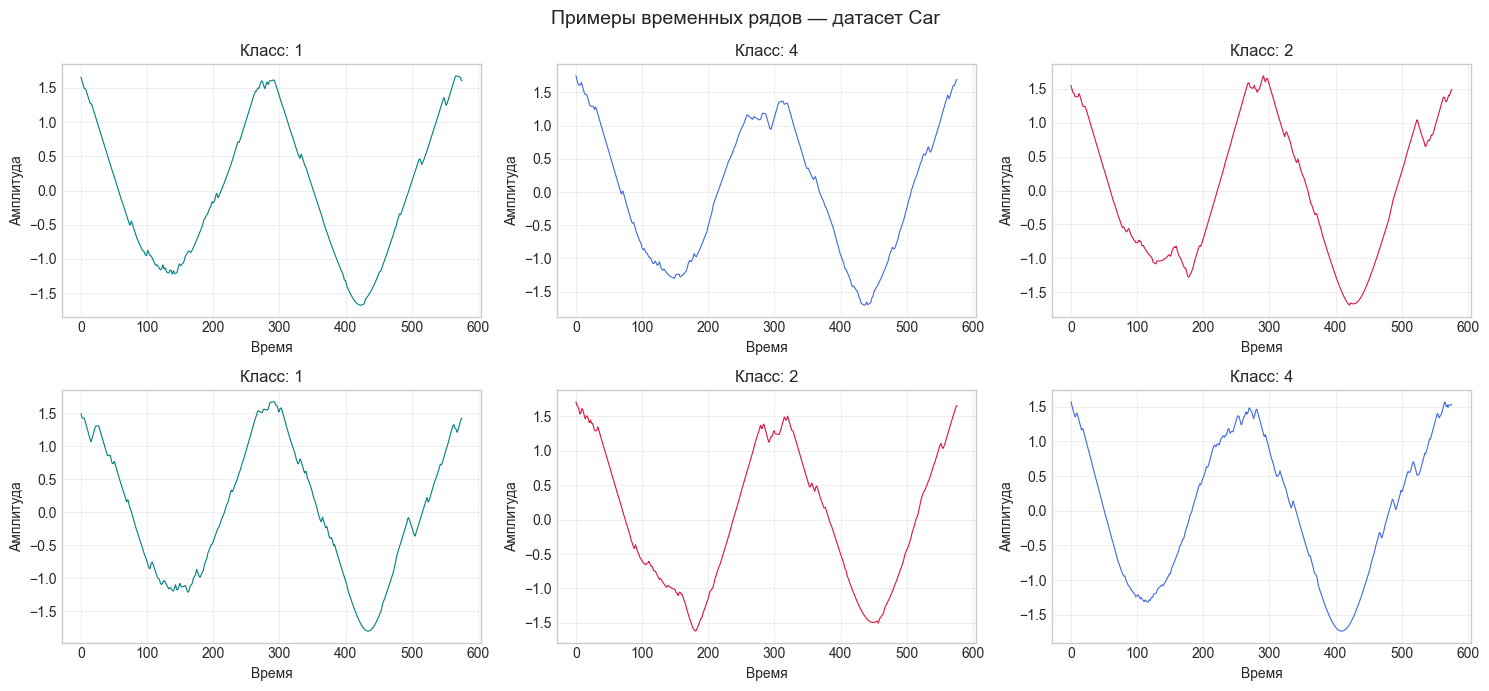

In [4]:
n_show = 6
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
axes = axes.flatten()

palette = ["teal", "crimson", "darkorange", "royalblue", "forestgreen", "purple"]
classes = np.unique(y_train)
color_map = {cls: palette[i % len(palette)] for i, cls in enumerate(classes)}

for i in range(n_show):
    col = color_map[y_train[i]]
    axes[i].plot(X_train[i, 0, :], color=col, linewidth=0.8)
    axes[i].set_title(f"Класс: {y_train[i]}", fontsize=12)
    axes[i].set_xlabel("Время", fontsize=10)
    axes[i].set_ylabel("Амплитуда", fontsize=10)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Примеры временных рядов — датасет Car", fontsize=14)
plt.tight_layout()
plt.show()

### DTW-расстояния

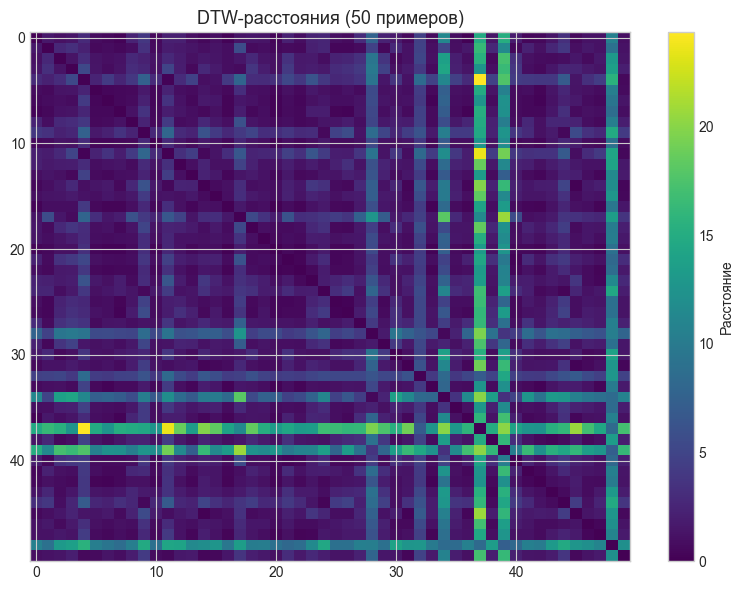

In [5]:
n_sub = min(50, X_train.shape[0])
X_sub = X_train[:n_sub]

dtw_dist = np.zeros((n_sub, n_sub))
for i in range(n_sub):
    for j in range(i+1, n_sub):
        d = dtw_distance(X_sub[i], X_sub[j])
        dtw_dist[i, j] = d
        dtw_dist[j, i] = d

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dtw_dist, cmap="viridis", aspect="auto")
ax.set_title(f"DTW-расстояния ({n_sub} примеров)", fontsize=13)
plt.colorbar(im, ax=ax, label="Расстояние")
plt.tight_layout()
plt.show()

### KNN с DTW

In [6]:
from aeon.classification.distance_based import KNeighborsTimeSeriesClassifier

knn_dtw = KNeighborsTimeSeriesClassifier(
    distance="dtw",
    n_neighbors=3
)
knn_dtw.fit(X_train, y_train)
y_pred = knn_dtw.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"KNN-DTW точность: {acc:.4f} ({acc*100:.2f}%)")

KNN-DTW точность: 0.7333 (73.33%)


### Rocket-классификаторы

In [7]:
from aeon.classification.convolution_based import RocketClassifier, MiniRocketClassifier

rocket = RocketClassifier(n_kernels=10000, random_state=42)
rocket.fit(X_train, y_train)
y_pred_rocket = rocket.predict(X_test)
acc_rocket = accuracy_score(y_test, y_pred_rocket)
print(f"Rocket точность: {acc_rocket:.4f} ({acc_rocket*100:.2f}%)")

minirocket = MiniRocketClassifier(random_state=42)
minirocket.fit(X_train, y_train)
y_pred_mr = minirocket.predict(X_test)
acc_mr = accuracy_score(y_test, y_pred_mr)
print(f"MiniRocket точность: {acc_mr:.4f} ({acc_mr*100:.2f}%)")

Rocket точность: 0.9167 (91.67%)


MiniRocket точность: 0.9167 (91.67%)


### Catch22

In [8]:
from aeon.classification.feature_based import Catch22Classifier

catch22 = Catch22Classifier(random_state=42)
catch22.fit(X_train, y_train)
y_pred_c22 = catch22.predict(X_test)
acc_c22 = accuracy_score(y_test, y_pred_c22)
print(f"Catch22 точность: {acc_c22:.4f} ({acc_c22*100:.2f}%)")

Catch22 точность: 0.7500 (75.00%)


### Сравнение методов

In [9]:
import pandas as pd

results = pd.DataFrame({
    "Метод": ["KNN-DTW", "Rocket", "MiniRocket", "Catch22"],
    "Точность": [f"{acc:.4f}", f"{acc_rocket:.4f}", f"{acc_mr:.4f}", f"{acc_c22:.4f}"]
})
print(results.to_string(index=False))

     Метод Точность
   KNN-DTW   0.7333
    Rocket   0.9167
MiniRocket   0.9167
   Catch22   0.7500


KNN-DTW показал точность 73.33%. Для 4-классовой задачи это хороший результат, значительно выше случайного уровня (25%). DTW эффективно учитывает временные сдвиги при сравнении рядов.